# Pandora vs. TEMPO NO₂ Comparison — Whittier, CA

This notebook compares tropospheric NO₂ column measurements from two sources:
- **Pandora**: A ground-based spectrometer at a fixed site, providing high-temporal-resolution column NO₂
- **TEMPO**: NASA's Tropospheric Emissions: Monitoring of Pollution satellite instrument, providing spatially gridded NO₂ retrievals over North America

The workflow:
1. Fetch data from EPA's RSIG (Remote Sensing Information Gateway) API using `pyrsig`
2. Temporally align the two datasets by resampling to hourly medians
3. Compute an Orthogonal Distance Regression (ODR) to compare the two — ODR is preferred over OLS here because both variables have measurement uncertainty
4. Visualize the time series, scatter correlation, and hourly correlation patterns



## 1. Imports and Helper Functions
This part is kind of annoying, you have to run it. Then go up to runtime and hit restart session, and then run it again, or it won't find pyrsig

In [29]:
%matplotlib inline
%pip install --user pyrsig pycno pyproj netcdf4

import matplotlib.pyplot as plt
import pyrsig
import pandas as pd
import os
import datetime as dt
import scipy.odr as odr
from scipy import stats

In [30]:
def line(x, a, b):
    """Evaluate a line y = a*x + b. Used for plotting fitted lines."""
    return a * x + b

def odr_line(p, x):
    """ODR-compatible line model. ODR passes parameters as a vector p=(m, c)."""
    m, c = p
    return m * x + c

def perform_odr(x, y, xerr, yerr):
    """
    Perform Orthogonal Distance Regression (ODR) on paired (x, y) data
    with associated uncertainties (xerr, yerr).

    Unlike ordinary least-squares, ODR minimizes residuals perpendicular
    to the fit line, accounting for error in both variables. This is
    appropriate when neither instrument is a perfect reference.

    Parameters
    ----------
    x, y    : array-like, the two measurement series
    xerr, yerr : array-like, corresponding 1-sigma uncertainties

    Returns
    -------
    output : scipy.odr.Output object
        output.beta = [slope, intercept]
        output.sd_beta = standard errors on slope and intercept
    """
    linear = odr.Model(odr_line)
    mydata = odr.Data(x, y, wd=1./xerr, we=1./yerr)  # weights are 1/uncertainty
    # Bootstrap initial guess from standard linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    myodr = odr.ODR(mydata, linear, beta0=[slope, intercept])
    output = myodr.run()
    return output

## 2. Configure the RSIG API
This is where you configure what data you want to grab

**Study period:** Up to you

**Domain:** ~0.2° × 0.2° box centered on the Pandora site is a good start, but you can play with this

`pyrsig.RsigApi` handles authentication, caching, and data fetching from EPA's RSIG service. Key parameters:
- `bdate`/`edate`: temporal bounds in `YYYY-MM-DDTHH` format
- `bbox`: spatial bounding box as `(lon_min, lat_min, lon_max, lat_max)` — this ~0.2° box is centered on the Whittier Pandora site
- `workdir`: local cache directory; previously fetched data won't be re-downloaded if `overwrite=False`
- `pandora_kw={'minimum_quality': 'high'}`: filters Pandora retrievals to high-quality flag only

In [31]:
rsigapi = pyrsig.RsigApi(
    bdate='2025-05-01T00',
    edate='2025-07-30T00',
    bbox=(-118.13040, 33.87680, -117.9304, 34.07680),
    workdir='whittier',
    pandora_kw={'minimum_quality': 'high'},
    overwrite=False
)

# API key is not required for unvalidated TEMPO data releases.
# For validated/extended data, provide a key via:
#   api_key = open(os.path.expanduser('~/.tempokey'), 'r').read().strip()
api_key = 'none'
rsigapi.tempo_kw['api_key'] = api_key

## 3. Fetch Pandora and TEMPO NO₂ Data

Both datasets are fetched as `pandas` DataFrames via `rsigapi.to_dataframe()`.

- `parse_dates=True`: converts the time column to `datetime64` objects
- `unit_keys=False`: strips unit strings from column names (e.g., `no2 [molecules/cm2]` → `no2`)

In [32]:
# --- Pandora ---
# Product: L2 total and tropospheric NO2 from Pandora spectrometers
pandorakey = 'pandora.L2_rnvh3p1_8.tropospheric_nitrogen_dioxide'
pandoracol = 'tropospheric_nitrogen_dioxide'

padf = rsigapi.to_dataframe(pandorakey, parse_dates=True, unit_keys=False)
print(f"Pandora: {len(padf)} retrievals")
padf.head()

Using cached: whittier/pandora.L2_rnvh3p1_8.tropospheric_nitrogen_dioxide_2025-05-01T000000Z_2025-07-30T000000Z.csv.gz
Pandora: 2675 retrievals


,Timestamp,LONGITUDE,LATITUDE,ELEVATION,STATION,tropospheric_nitrogen_dioxide,NOTE,time
0,2025-05-01T17:19:14-0000,-118.0299,33.9768,130.0,247,8.442440e+15,Pandora247s1_WhittierCA_L2_rnvh3p1-8; College SLC,2025-05-01 17:19:14+00:00
1,2025-05-01T17:26:19-0000,-118.0299,33.9768,130.0,247,7.354239e+15,Pandora247s1_WhittierCA_L2_rnvh3p1-8; College SLC,2025-05-01 17:26:19+00:00
2,2025-05-01T17:33:22-0000,-118.0299,33.9768,130.0,247,7.742065e+15,Pandora247s1_WhittierCA_L2_rnvh3p1-8; College SLC,2025-05-01 17:33:22+00:00
3,2025-05-01T17:40:25-0000,-118.0299,33.9768,130.0,247,7.883585e+15,Pandora247s1_WhittierCA_L2_rnvh3p1-8; College SLC,2025-05-01 17:40:25+00:00
4,2025-05-01T17:50:01-0000,-118.0299,33.9768,130.0,247,6.989900e+15,Pandora247s1_WhittierCA_L2_rnvh3p1-8; College SLC,2025-05-01 17:50:01+00:00


In [33]:
# --- TEMPO ---
# Product: TEMPO L2 tropospheric NO2 vertical column
tempokey = 'tempo.l2.no2.vertical_column_troposphere'
tempocol = 'no2_vertical_column_troposphere'

tempodf = rsigapi.to_dataframe(tempokey, unit_keys=False, parse_dates=True)
print(f"TEMPO: {len(tempodf)} pixels within bounding box")
tempodf.head()

Using cached: whittier/tempo.l2.no2.vertical_column_troposphere_2025-05-01T000000Z_2025-07-30T000000Z.csv.gz
TEMPO: 32655 pixels within bounding box


,Timestamp,LONGITUDE,LATITUDE,no2_vertical_column_troposphere,Longitude_SW,Longitude_SE,Longitude_NW,Longitude_NE,Latitude_SW,Latitude_SE,Latitude_NW,Latitude_NE,time
0,2025-05-01T00:19:00-0000,-117.948280,34.068523,1.861116e+16,-117.920425,-117.983366,-117.912674,-117.975861,34.076138,34.079352,34.057307,34.060764,2025-05-01 00:19:00+00:00
1,2025-05-01T00:19:00-0000,-118.010941,34.071590,2.283726e+16,-117.983366,-118.045752,-117.975861,-118.038298,34.079352,34.082536,34.060764,34.064011,2025-05-01 00:19:00+00:00
2,2025-05-01T00:19:00-0000,-118.073105,34.074955,2.567463e+16,-118.045752,-118.107958,-118.038298,-118.100559,34.082536,34.085411,34.064011,34.066953,2025-05-01 00:19:00+00:00
3,2025-05-01T00:19:00-0000,-117.940788,34.049934,1.353741e+16,-117.912674,-117.975861,-117.905020,-117.968332,34.057307,34.060764,34.038557,34.042149,2025-05-01 00:19:00+00:00
4,2025-05-01T00:19:00-0000,-118.003433,34.053009,1.838248e+16,-117.975861,-118.038298,-117.968332,-118.030790,34.060764,34.064011,34.042149,34.045432,2025-05-01 00:19:00+00:00


## 4. Time Series: Quick Look

Before computing correlations, it's useful to visually compare the two time series. We resample to common temporal bins:
- **Pandora**: 15-minute medians (900 s), Pandora temporal resolution can vary depending on light intensity, which will impact the time it takes to go through a measurement. This ensures a consistent value throughout the time period.
- **TEMPO**: 1-hour medians (spatial median across all pixels within the bounding box per overpass)

In [34]:
# Pandora: 15-min spatial medians
gb_pan = pd.Grouper(key='time', freq='900s')
pads = padf.groupby(gb_pan).median(numeric_only=True)[pandoracol]

# TEMPO: 1-hour spatial medians
gb_tempo = pd.Grouper(key='time', freq='1h')
tempods = tempodf.groupby(gb_tempo).median(numeric_only=True)[tempocol]

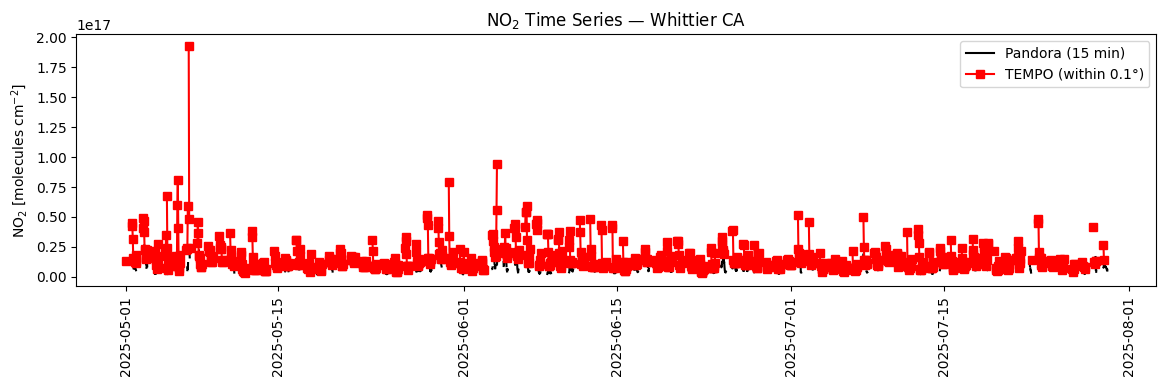

In [35]:
gkw = dict(bottom=0.25, left=0.05, right=0.95)
fig, ax = plt.subplots(figsize=(12, 4), gridspec_kw=gkw)
ax.tick_params(axis='x', labelrotation=90)

ax.plot(pads.index.values, pads.values, color='k', label='Pandora (15 min)')
ax.plot(tempods.index.values, tempods.values,
        marker='s', color='r', label='TEMPO (within 0.1°)')

ax.set(ylabel='NO$_2$ [molecules cm$^{-2}$]',
       title='NO$_2$ Time Series — Whittier CA')
ax.legend()
plt.show()

## 5. Hourly Resampling for Correlation Analysis

To directly compare the two instruments we need co-located, co-temporal measurements. We resample both to **1-hour means/medians** (currently means) and also compute **hourly standard deviations**, which serve as uncertainty estimates for ODR.

- Pandora → hourly **mean** (many observations per hour)
- TEMPO → hourly **mean** (robust against outlier pixels)
- Uncertainty → hourly **std** for each instrument

In [36]:
# Set time as index for resampling
padf.index = padf.time
tempodf.index = tempodf.time

# Central tendency
pandora_no2_hourly = padf.resample('60min').mean(numeric_only=True)
tempo_no2_hourly = tempodf.resample('60min').mean(numeric_only=True)

# Spread (used as uncertainty weights in ODR)
err_tempo_no2_hourly = tempodf.resample('60min').std(numeric_only=True)
err_pandora_no2_hourly = padf.resample('60min').std(numeric_only=True)

# Merge central tendency with uncertainty into single frames
# Columns: variable_x = central tendency, variable_y = std
tempo_err_frame = tempo_no2_hourly.merge(
    err_tempo_no2_hourly, left_index=True, right_index=True
)
pandora_err_frame = pandora_no2_hourly.merge(
    err_pandora_no2_hourly, left_index=True, right_index=True
)

## 6. Merge Datasets and Compute ODR

We inner-join on the hourly timestamp index, keeping only hours where **both** instruments have valid (non-NaN) data. We also convert from UTC to local time for interpretable diurnal labeling.

In [37]:
# Merge central tendency values
combo = tempo_no2_hourly.merge(pandora_no2_hourly, left_index=True, right_index=True)
combo = combo.dropna(subset=[pandoracol, tempocol])
combo = combo.tz_convert('America/Los_Angeles')   # UTC → PST/PDT
combo['hour'] = combo.index.hour

print(f"Matched hourly pairs: {len(combo)}")
combo[[tempocol, pandoracol, 'hour']].describe()

Matched hourly pairs: 591


,no2_vertical_column_troposphere,tropospheric_nitrogen_dioxide,hour
count,5.910000e+02,5.910000e+02,591.000000
mean,1.514420e+16,6.833896e+15,12.431472
std,1.115253e+16,3.900624e+15,2.801626
min,3.479830e+15,1.892518e+15,7.000000
25%,8.536504e+15,4.003131e+15,10.000000
50%,1.143163e+16,5.758899e+15,12.000000
75%,1.712976e+16,8.352610e+15,15.000000
max,8.869309e+16,2.369941e+16,18.000000


In [38]:
# Merge uncertainty frames (needed for ODR weights)
combo_err = tempo_err_frame.merge(pandora_err_frame, left_index=True, right_index=True)
combo_err = combo_err.dropna(
    subset=['tropospheric_nitrogen_dioxide_y', 'no2_vertical_column_troposphere_x']
)

# Column naming after two merges:
#   no2_vertical_column_troposphere_x  = TEMPO hourly median
#   no2_vertical_column_troposphere_y  = TEMPO hourly std (uncertainty)
#   tropospheric_nitrogen_dioxide_x    = Pandora hourly mean
#   tropospheric_nitrogen_dioxide_y    = Pandora hourly std (uncertainty)

no2_regression = perform_odr(
    combo_err.tropospheric_nitrogen_dioxide_x,    # Pandora (x)
    combo_err.no2_vertical_column_troposphere_x,  # TEMPO (y)
    combo_err.tropospheric_nitrogen_dioxide_y,    # Pandora uncertainty
    combo_err.no2_vertical_column_troposphere_y   # TEMPO uncertainty
)

print("ODR results:")
print(f"  Slope:     {no2_regression.beta[0]:.3f} ± {no2_regression.sd_beta[0]:.3f}")
print(f"  Intercept: {no2_regression.beta[1]:.3e} ± {no2_regression.sd_beta[1]:.3e}")

ODR results:
  Slope:     1.935 ± 0.099
  Intercept: 3.619e+14 ± 6.065e+14


## 7. Correlation Plots

Two panels:
1. **Scatter plot** (left): Each point is one matched hourly pair, colored by local hour. The ODR fit line is plotted alongside the 1:1 line as a reference.
2. **Hourly correlation** (right): Pearson *r* between Pandora and TEMPO as a function of local hour — useful for identifying times of day where agreement is best. In Whittier this is typically mid-morning through early afternoon when TEMPO has good coverage and boundary layer dynamics are simpler. It might be different for you!

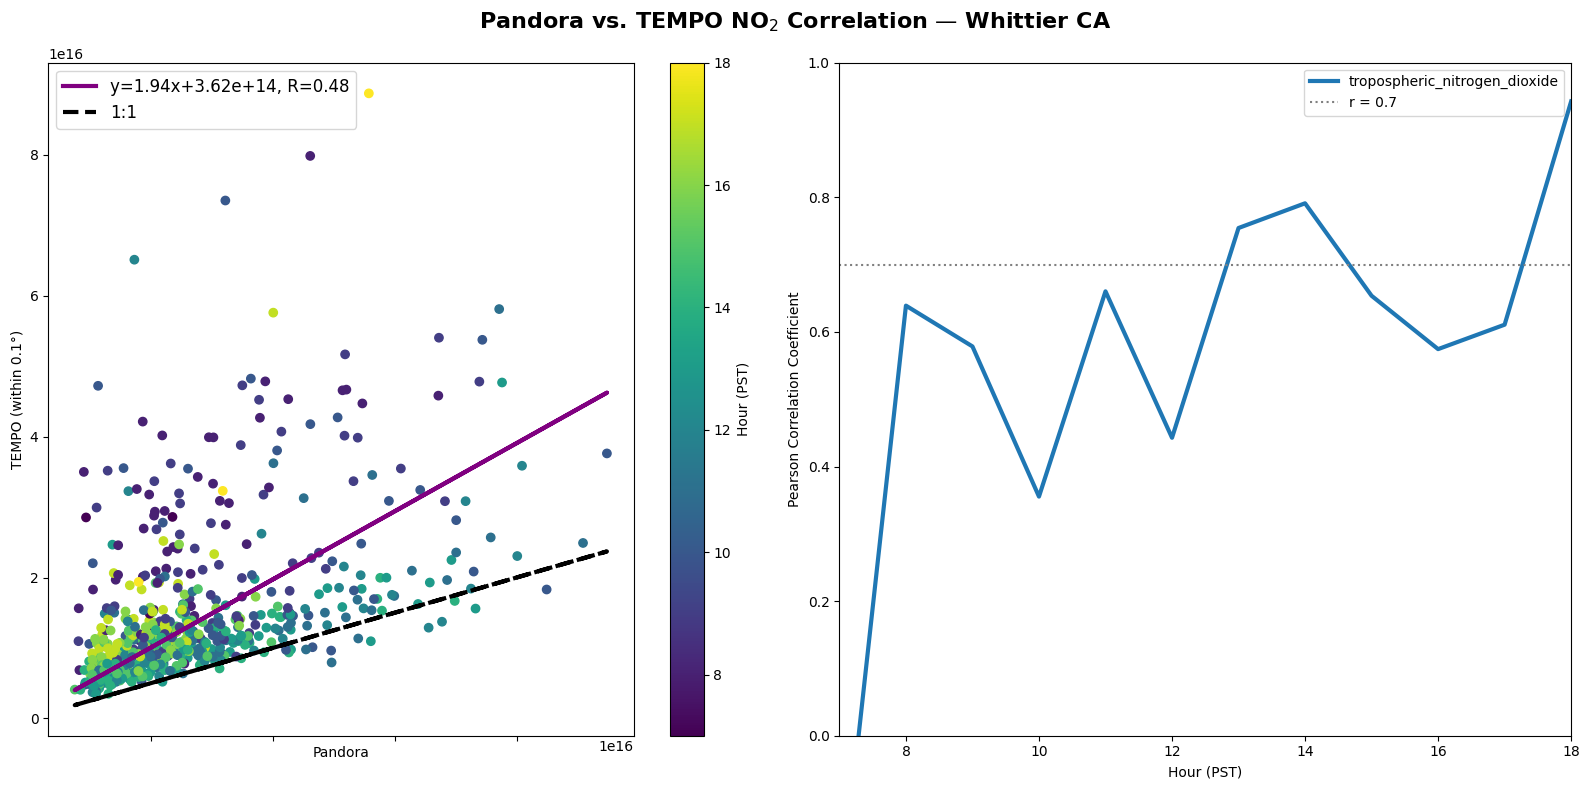

In [39]:
# Standard linear regression (for R value to annotate plot)
slope_ols, intercept_ols, r_value, p_value, std_err_ols = stats.linregress(
    combo.tropospheric_nitrogen_dioxide,
    combo.no2_vertical_column_troposphere
)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# --- Panel 1: Scatter with ODR fit ---
hb = ax[0].scatter(
    combo.tropospheric_nitrogen_dioxide,
    combo.no2_vertical_column_troposphere,
    c=combo.hour
)

# ODR fit line
ax[0].plot(
    combo.tropospheric_nitrogen_dioxide,
    line(combo.tropospheric_nitrogen_dioxide,
         no2_regression.beta[0], no2_regression.beta[1]),
    label='y={:.2f}x+{:.2e}, R={:.2f}'.format(
        no2_regression.beta[0], no2_regression.beta[1], r_value
    ),
    lw=3, color='purple'
)

# 1:1 reference line
ax[0].plot(
    combo.tropospheric_nitrogen_dioxide,
    line(combo.tropospheric_nitrogen_dioxide, 1, 0),
    label='1:1', lw=3, ls='--', color='k'
)

ax[0].set(xlabel='Pandora', ylabel='TEMPO (within 0.1°)')
ax[0].legend(fontsize=12)
plt.setp(ax[0].get_xticklabels(), visible=False)  # suppress x tick labels (units in axis label)

cb = plt.colorbar(hb, ax=ax[0])
cb.set_label('Hour (PST)')

# --- Panel 2: Hourly correlation coefficient ---
no2_corr = combo.groupby('hour')['tropospheric_nitrogen_dioxide'].corr(
    combo['no2_vertical_column_troposphere']
)
no2_corr.plot(ax=ax[1], lw=3)
ax[1].set(
    ylabel='Pearson Correlation Coefficient',
    xlabel='Hour (PST)',
    xlim=[7, 18],
    ylim=[0, 1]
)
ax[1].axhline(0.7, ls=':', color='gray', label='r = 0.7')  # reference line
ax[1].legend()

fig.suptitle('Pandora vs. TEMPO NO$_2$ Correlation — Whittier CA', fontsize=16, fontweight='bold')
fig.tight_layout()
# fig.savefig('whittier_no2_correlation.png', dpi=300)
plt.show()